In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os
from PIL import Image

from myDataset import *

# imports loss, accuracy and confusion matrix plots
from MetricMethods import *

# imports train, test methods
from ArchitectureMethods import *



seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.empty_cache()

# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/Custom All
/user/HS401/ob00564/Documents/COM3001
cuda


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9602616].


Train set length: 3241
Test set length: 404
Validation set length: 408
torch.Size([3, 224, 224]) 0
0


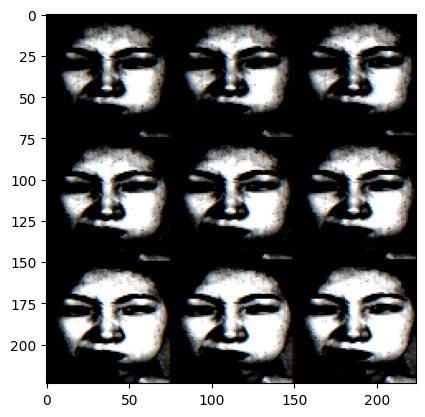

In [2]:
# Dataset Creation
train_dataset = myDataset(directory = "Custom All/DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "Custom All/DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "Custom All/DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

# DataLoader Creation
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)

# View shape of data
train_iter = iter(train_dataset)
img, label = next(train_iter)
print(img.shape, label)

np_img = img.numpy()
print(label)
plt.imshow(np_img.reshape((224,224,3)))



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class ArchitectureFour(nn.Module):
    
    def __init__(self):
        super(ArchitectureFour, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size = 3, stride = 1, padding = 1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)  

        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.batch_norm3 = nn.BatchNorm2d(128)
        self.batch_norm4 = nn.BatchNorm2d(256)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(14 * 14 * 256, 256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128, 7)

        self.dropout1 = nn.Dropout(p=0.5)
        self.dropout2 = nn.Dropout(p=0.5)
        self.dropout3 = nn.Dropout(p=0.5)
        self.dropout4 = nn.Dropout(p=0.5)

    def forward(self, x):

        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)
        # Output = 112 x 112 x 32

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout2(x)
         # Output = 56 x 56 x 64

        x = self.conv3(x)
        x = self.batch_norm3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout3(x)
         # Output = 28 x 28 x 128

        x = self.conv4(x)
        x = self.batch_norm4(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout4(x)
         # Output = 14 x 14 x 256

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)

        return x


100%|██████████| 203/203 [00:18<00:00, 10.81it/s]


Adam
Epoch 1/50, Training Loss: 2.0202, Validation Loss: 1.9141
Epoch 1/50, Training Acc: 29.259031198686376, Validation Accuracy: 12.01923076923077
SGD
Epoch 1/50, Training Loss: 1.9988, Validation Loss: 1.9087
Epoch 1/50, Training Acc: 25.547345374931584, Validation Accuracy: 24.278846153846153


100%|██████████| 203/203 [00:13<00:00, 15.47it/s]


Adam
Epoch 2/50, Training Loss: 1.4918, Validation Loss: 1.7158
Epoch 2/50, Training Acc: 45.76491516146689, Validation Accuracy: 34.13461538461539
SGD
Epoch 2/50, Training Loss: 1.6732, Validation Loss: 1.7365
Epoch 2/50, Training Acc: 35.495347564313086, Validation Accuracy: 44.47115384615385


100%|██████████| 203/203 [00:09<00:00, 22.15it/s]


...

Adam
Epoch 48/50, Training Loss: 0.8289, Validation Loss: 0.9040
Epoch 48/50, Training Acc: 72.2495894909688, Validation Accuracy: 67.54807692307693
SGD
Epoch 48/50, Training Loss: 0.3943, Validation Loss: 0.4780
Epoch 48/50, Training Acc: 85.22851669403393, Validation Accuracy: 84.13461538461539


100%|██████████| 203/203 [00:12<00:00, 16.63it/s]


Adam
Epoch 49/50, Training Loss: 0.8282, Validation Loss: 0.8828
Epoch 49/50, Training Acc: 72.45826491516146, Validation Accuracy: 69.47115384615384
SGD
Epoch 49/50, Training Loss: 0.3645, Validation Loss: 0.4856
Epoch 49/50, Training Acc: 86.4908319649699, Validation Accuracy: 83.65384615384616


100%|██████████| 203/203 [00:09<00:00, 21.92it/s]


Adam
Epoch 50/50, Training Loss: 0.8307, Validation Loss: 0.9009
Epoch 50/50, Training Acc: 72.75930487137383, Validation Accuracy: 69.47115384615384
SGD
Epoch 50/50, Training Loss: 0.3650, Validation Loss: 0.4594
Epoch 50/50, Training Acc: 86.8602900930487, Validation Accuracy: 83.89423076923077
Models saved successfully!
Test Adam Loss: 0.8857, Test Adam Accuracy: 67.65%
Test SGD Loss: 0.5441, Test SGD Accuracy: 82.60%


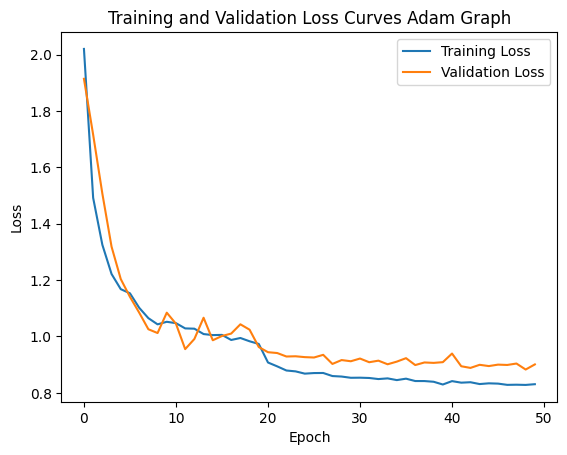

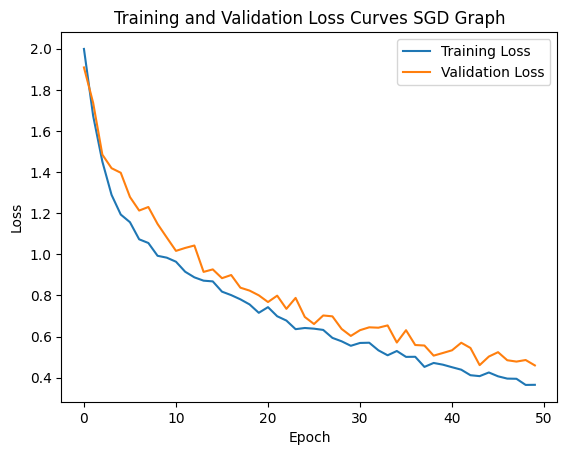

In [4]:
# Train and Test of Architecture Two using *un-weighted* Cross-Entropy Loss function

# Model Instance
model_one_a = ArchitectureFour().to(device)
model_one_b = ArchitectureFour().to(device)

# Epochs
num_epochs = 50

# Optimizer
adamOptimizer = optim.Adam(model_one_a.parameters(), lr=0.00005, weight_decay=0.5)
sdgOptimizer = optim.SGD(model_one_b.parameters(), lr=0.001, momentum=0.93, weight_decay=0.01)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Learning Rate Scheduler
adam_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(adamOptimizer, mode='min', factor=0.1, patience=7)
sdg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(sdgOptimizer, mode='min', factor=0.1, patience=7)

(unweighted_train_losses_a, unweighted_val_losses_a, unweighted_train_accuracy_a, unweighted_val_accuracy_a, 
 unweighted_train_losses_b, unweighted_val_losses_b, unweighted_train_accuracy_b, unweighted_val_accuracy_b) = train(model_one_a, model_one_b, device, train_loader, val_loader, 
                                                                                                                        adamOptimizer, sdgOptimizer, adam_scheduler, sdg_scheduler, num_epochs, criterion, 
                                                                                                                        'Custom All/Architecture Four/Unweighted Architecture Four Adam.pth', 
                                                                                                                        'Custom All/Architecture Four/Unweighted Architecture Four SGD.pth')

a_y_true, a_y_pred, a_y_score = test(model_one_a, device, criterion, test_loader, split='Test Adam')
b_y_true, b_y_pred, b_y_score = test(model_one_b, device, criterion, test_loader, split='Test SGD')

# Print metrics a
lossPlot(unweighted_train_losses_a, unweighted_val_losses_a, 'Adam Graph')

# Print metrics b
lossPlot(unweighted_train_losses_b, unweighted_val_losses_b, 'SGD Graph')


{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]


100%|██████████| 203/203 [00:09<00:00, 22.09it/s]


Adam
Epoch 1/50, Training Loss: 2.0615, Validation Loss: 1.8803
Epoch 1/50, Training Acc: 26.580459770114945, Validation Accuracy: 16.826923076923077
SGD
Epoch 1/50, Training Loss: 2.0448, Validation Loss: 1.9023
Epoch 1/50, Training Acc: 22.73193760262726, Validation Accuracy: 15.865384615384615


100%|██████████| 203/203 [00:09<00:00, 21.99it/s]


Adam
Epoch 2/50, Training Loss: 1.6363, Validation Loss: 1.7437
Epoch 2/50, Training Acc: 40.58908045977011, Validation Accuracy: 49.519230769230774
SGD
Epoch 2/50, Training Loss: 1.6093, Validation Loss: 1.5072
Epoch 2/50, Training Acc: 40.2811986863711, Validation Accuracy: 45.43269230769231


...

Adam
Epoch 48/50, Training Loss: 1.0398, Validation Loss: 1.0410
Epoch 48/50, Training Acc: 66.17747673782156, Validation Accuracy: 70.1923076923077
SGD
Epoch 48/50, Training Loss: 0.3767, Validation Loss: 0.4682
Epoch 48/50, Training Acc: 87.25369458128078, Validation Accuracy: 81.49038461538461


100%|██████████| 203/203 [00:11<00:00, 17.19it/s]


Adam
Epoch 49/50, Training Loss: 1.0529, Validation Loss: 1.0028
Epoch 49/50, Training Acc: 65.55487137383689, Validation Accuracy: 67.3076923076923
SGD
Epoch 49/50, Training Loss: 0.3600, Validation Loss: 0.4784
Epoch 49/50, Training Acc: 88.21496989600438, Validation Accuracy: 80.04807692307693


100%|██████████| 203/203 [00:19<00:00, 10.51it/s]


Adam
Epoch 50/50, Training Loss: 1.0443, Validation Loss: 1.0090
Epoch 50/50, Training Acc: 66.54693486590037, Validation Accuracy: 68.99038461538461
SGD
Epoch 50/50, Training Loss: 0.3658, Validation Loss: 0.4819
Epoch 50/50, Training Acc: 87.25369458128078, Validation Accuracy: 80.04807692307693
Models saved successfully!
Test Adam Loss: 1.0160, Test Adam Accuracy: 64.95%
Test SGD Loss: 0.5838, Test SGD Accuracy: 80.39%


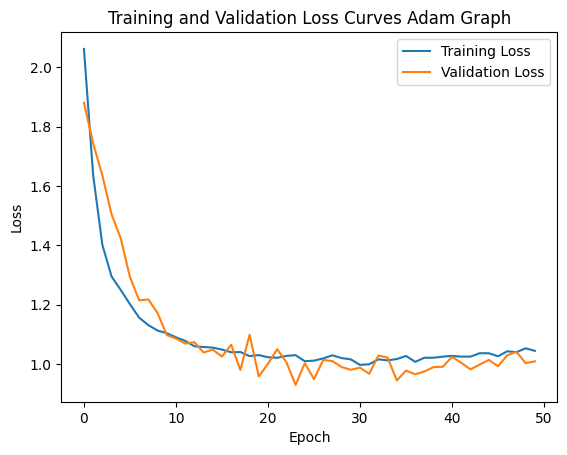

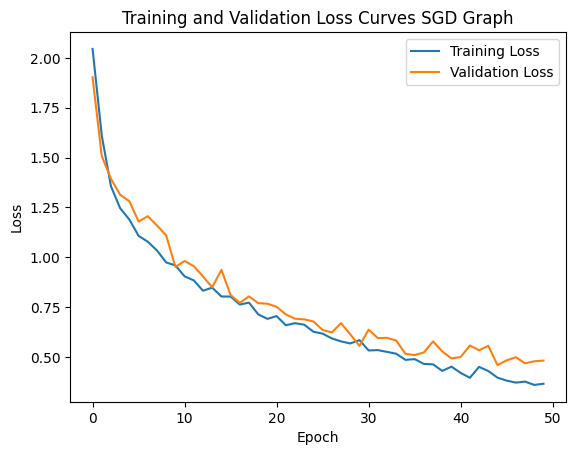

In [5]:
# Train and Test of ArchitectureOne using *weighted* Cross-Entropy Loss function
# Model Instance
model_one_weighted_a = ArchitectureFour().to(device)
model_one_weighted_b = ArchitectureFour().to(device)

# Epochs
num_epochs = 50

# Optimizer
weighted_adamOptimizer = optim.Adam(model_one_weighted_a.parameters(), lr=0.00005, weight_decay=0.5)
weighted_sgdOptimizer = optim.SGD(model_one_weighted_b.parameters(), lr=0.001, momentum=0.93, weight_decay=0.01)

# Loss Function
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))

# Learning Rate Scheduler
# Learning Rate Scheduler
adam_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(adamOptimizer, mode='min', factor=0.1, patience=7)
sdg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(sdgOptimizer, mode='min', factor=0.1, patience=7)

(weighted_train_losses_a, weighted_val_losses_a, weighted_train_accuracy_a, weighted_val_accuracy_a, 
 weighted_train_losses_b, weighted_val_losses_b, weighted_train_accuracy_b, weighted_val_accuracy_b) = train(model_one_weighted_a, model_one_weighted_b, device, train_loader, val_loader, 
                                                                                                                    weighted_adamOptimizer, weighted_sgdOptimizer, lr_scheduler_a= adam_scheduler, lr_scheduler_b=sdg_scheduler, 
                                                                                                                    num_epochs=num_epochs, criterion=criterion, 
                                                                                                                    name_a= 'Custom All/Architecture Four/Weighted Architecture Four Adam.pth', 
                                                                                                                    name_b= 'Custom All/Architecture Four/Weighted Architecture Four SGD.pth')

a_y_true, a_y_pred, a_y_score = test(model_one_weighted_a, device, criterion, test_loader, split='Test Adam')
b_y_true, b_y_pred, b_y_score = test(model_one_weighted_b, device, criterion, test_loader, split='Test SGD')

# Print metrics a
lossPlot(weighted_train_losses_a, weighted_val_losses_a, 'Adam Graph')

# Print metrics b
lossPlot(weighted_train_losses_b, weighted_val_losses_b, 'SGD Graph')


**Analysis & Improvements**:

Changes made:
* Add additional convolutional layer

Using figures above (unweighted):
* Adam:
    * Training is more stable &  overfitting
* SGD:
    * Training is far more stable,  overfits 

Using figures above (weighted):
* Adam:
    * Training is more stable & less overfitting
    * Training is far more stable & overfitting

Overall, the training loss and validating loss are beginning to decrease at a similar rate, however issues still occuring:
* Overfitting: the loss curves are divering less from training curves, still occuring but lesser


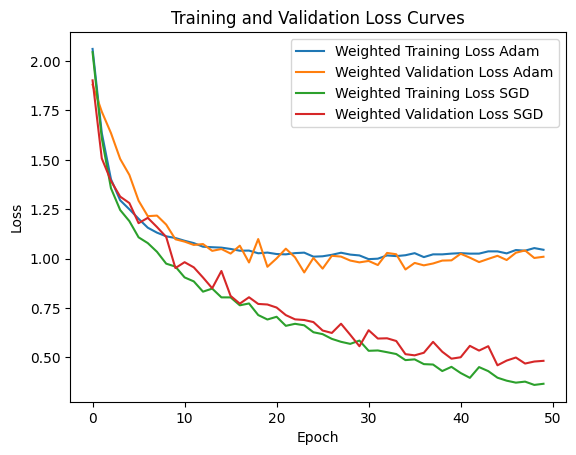

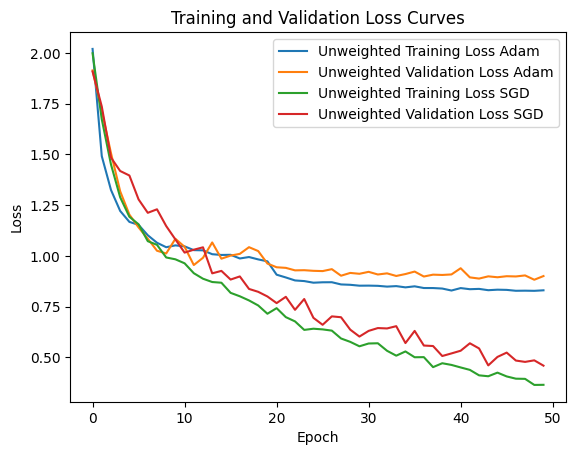

Adam unweighted Split Loss: 0.8857, Adam unweighted Split Accuracy: 67.65%
SGD unweighted Split Loss: 0.5441, SGD unweighted Split Accuracy: 82.60%
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Adam weighted Split Loss: 1.0160, Adam weighted Split Accuracy: 64.95%
SGD weighted Split Loss: 0.5838, SGD weighted Split Accuracy: 80.39%
Fin


In [6]:
def lossPlotUnWeighted():
    if any(x > 3 for x in unweighted_train_losses_a) or any(x > 3 for x in unweighted_val_losses_a) :
        plt.ylim(0,3)
    plt.plot(unweighted_train_losses_a, label='Unweighted Training Loss Adam')
    plt.plot(unweighted_val_losses_a, label='Unweighted Validation Loss Adam')

    plt.plot(unweighted_train_losses_b, label='Unweighted Training Loss SGD')
    plt.plot(unweighted_val_losses_b, label='Unweighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():
    if any(x > 3 for x in weighted_train_losses_a) or any(x > 3 for x in weighted_val_losses_a) :
        plt.ylim(0,3)
    plt.plot(weighted_train_losses_a, label='Weighted Training Loss Adam')
    plt.plot(weighted_val_losses_a, label='Weighted Validation Loss Adam')

    plt.plot(weighted_train_losses_b, label='Weighted Training Loss SGD')
    plt.plot(weighted_val_losses_b, label='Weighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

criterion = nn.CrossEntropyLoss()
test(model_one_a, device, criterion, test_loader, 'Adam unweighted Split')
test(model_one_b, device, criterion, test_loader, 'SGD unweighted Split')

criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
test(model_one_weighted_a, device, criterion, test_loader, 'Adam weighted Split')
test(model_one_weighted_b, device, criterion, test_loader, 'SGD weighted Split')

print('Fin')


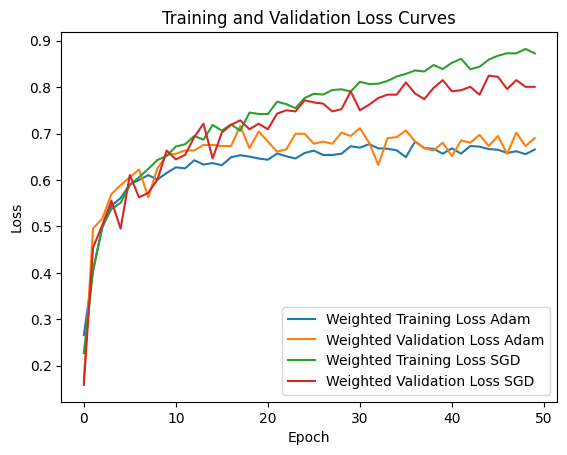

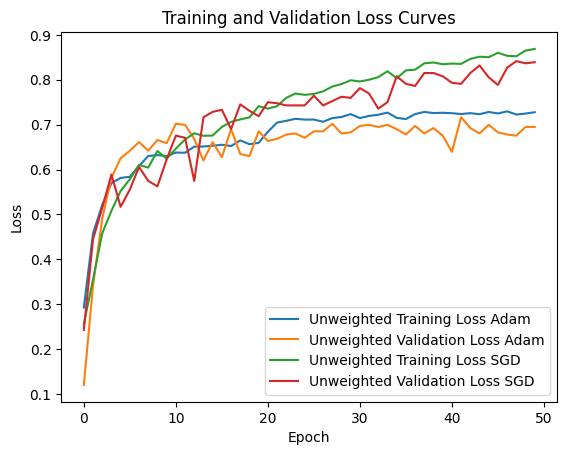

Adam unweighted Split Loss: 0.8857, Adam unweighted Split Accuracy: 67.65%
SGD unweighted Split Loss: 0.5441, SGD unweighted Split Accuracy: 82.60%
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Adam weighted Split Loss: 1.0160, Adam weighted Split Accuracy: 64.95%
SGD weighted Split Loss: 0.5838, SGD weighted Split Accuracy: 80.39%
Fin


In [12]:
def lossPlotUnWeighted():
    plt.plot(unweighted_train_accuracy_a, label='Unweighted Training Loss Adam')
    plt.plot(unweighted_val_accuracy_a, label='Unweighted Validation Loss Adam')

    plt.plot(unweighted_train_accuracy_b, label='Unweighted Training Loss SGD')
    plt.plot(unweighted_val_accuracy_b, label='Unweighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():

    plt.plot(weighted_train_accuracy_a, label='Weighted Training Loss Adam')
    plt.plot(weighted_val_accuracy_a, label='Weighted Validation Loss Adam')

    plt.plot(weighted_train_accuracy_b, label='Weighted Training Loss SGD')
    plt.plot(weighted_val_accuracy_b, label='Weighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

criterion = nn.CrossEntropyLoss()
test(model_one_a, device, criterion, test_loader, 'Adam unweighted Split')
test(model_one_b, device, criterion, test_loader, 'SGD unweighted Split')

criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
test(model_one_weighted_a, device, criterion, test_loader, 'Adam weighted Split')
test(model_one_weighted_b, device, criterion, test_loader, 'SGD weighted Split')

print('Fin')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3505400/2118986419.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Four/Unweighted Architectur

Unweighted Adam Test Loss: 0.8857, Unweighted Adam Test Accuracy: 67.65%
              precision    recall  f1-score   support

       Anger     0.7000    0.5600    0.6222        50
     Disgust     0.7105    0.5294    0.6067        51
        Fear     0.4167    0.1042    0.1667        48
   Happiness     0.8182    0.8654    0.8411        52
     Sadness     0.8000    0.3333    0.4706        48
    Surprise     0.5652    0.9630    0.7123        54
     Neurtal     0.6821    0.9810    0.8047       105

    accuracy                         0.6765       408
   macro avg     0.6704    0.6195    0.6035       408
weighted avg     0.6724    0.6765    0.6356       408



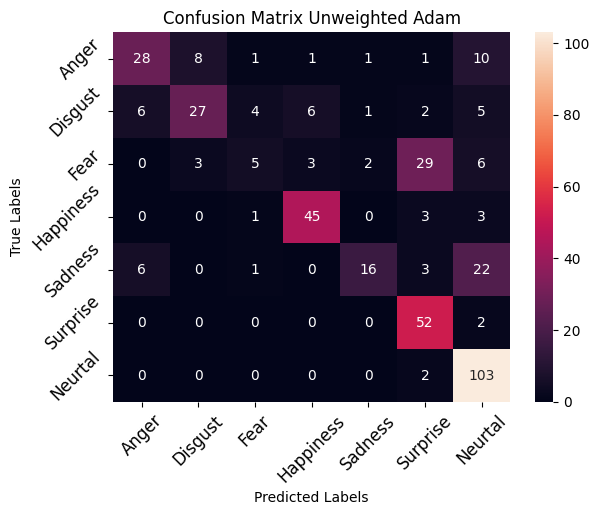

In [8]:
myModel = ArchitectureFour()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Four/Unweighted Architecture Four Adam.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss()
a_unweighted_y_true, a_unweighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted Adam Test')
confusionMatrixPlot(y_true=a_unweighted_y_true, y_pred=a_unweighted_y_pred, title= 'Unweighted Adam')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3505400/3985691501.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Four/Unweighted Architectur

Unweighted SGD Test Loss: 0.5441, Unweighted SGD Test Accuracy: 82.60%
              precision    recall  f1-score   support

       Anger     0.8649    0.6400    0.7356        50
     Disgust     0.7925    0.8235    0.8077        51
        Fear     0.6078    0.6458    0.6263        48
   Happiness     0.9412    0.9231    0.9320        52
     Sadness     0.7805    0.6667    0.7191        48
    Surprise     0.7761    0.9630    0.8595        54
     Neurtal     0.9259    0.9524    0.9390       105

    accuracy                         0.8260       408
   macro avg     0.8127    0.8021    0.8027       408
weighted avg     0.8293    0.8260    0.8236       408



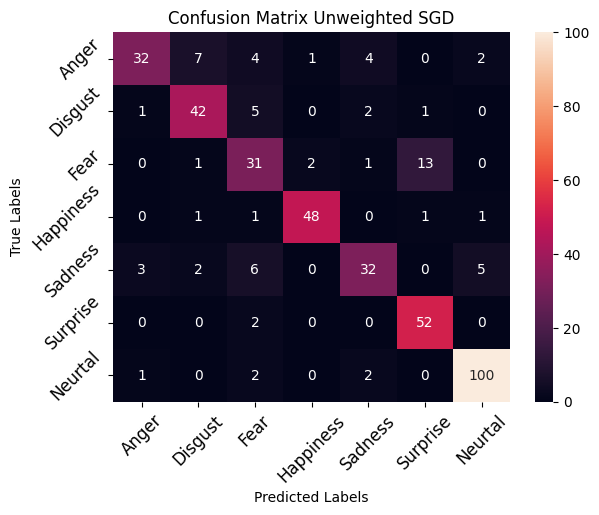

In [9]:
myModel = ArchitectureFour()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Four/Unweighted Architecture Four SGD.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss()
b_unweighted_y_true, b_unweighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted SGD Test')
confusionMatrixPlot(y_true=b_unweighted_y_true, y_pred=b_unweighted_y_pred, title= 'Unweighted SGD')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3505400/3271655854.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Four/Weighted Architecture 

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Weighted Adam Test Loss: 1.0160, Weighted Adam Test Accuracy: 64.95%
              precision    recall  f1-score   support

       Anger     0.4714    0.6600    0.5500        50
     Disgust     0.6122    0.5882    0.6000        51
        Fear     0.5000    0.1250    0.2000        48
   Happiness     0.9048    0.7308    0.8085        52
     Sadness     0.5532    0.5417    0.5474        48
    Surprise     0.5761    0.9815    0.7260        54
     Neurtal     0.8229    0.7524    0.7861       105

    accuracy                         0.6495       408
   macro avg     0.6344    0.6256    0.6026       408
weighted avg     0.6615    0.6495    0.6318       408



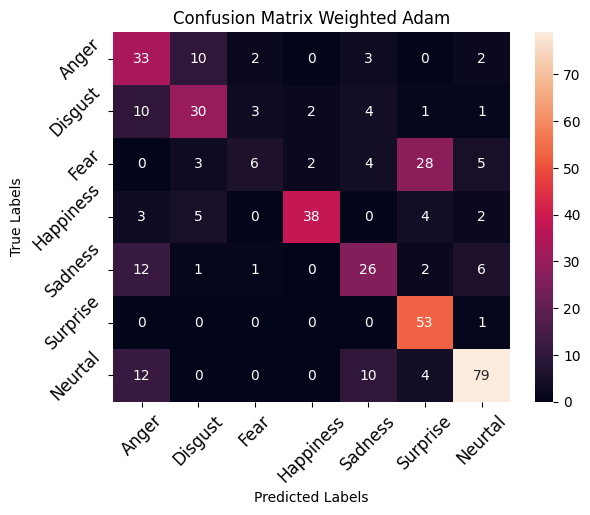

In [10]:
myModel = ArchitectureFour()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Four/Weighted Architecture Four Adam.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
a_weighted_y_true, a_weighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted Adam Test')
confusionMatrixPlot(a_weighted_y_true, a_weighted_y_pred, title= 'Weighted Adam')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3505400/1738309168.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Four/Weighted Architecture 

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Weighted SGD Test Loss: 0.5838, Weighted SGD Test Accuracy: 80.39%
              precision    recall  f1-score   support

       Anger     0.7091    0.7800    0.7429        50
     Disgust     0.7193    0.8039    0.7593        51
        Fear     0.7586    0.4583    0.5714        48
   Happiness     0.9216    0.9038    0.9126        52
     Sadness     0.7200    0.7500    0.7347        48
    Surprise     0.7260    0.9815    0.8346        54
     Neurtal     0.9677    0.8571    0.9091       105

    accuracy                         0.8039       408
   macro avg     0.7889    0.7907    0.7807       408
weighted avg     0.8134    0.8039    0.8003       408



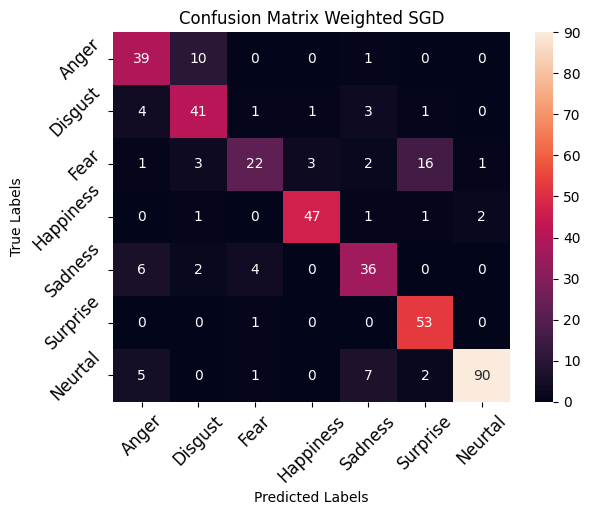

In [11]:
myModel = ArchitectureFour()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Four/Weighted Architecture Four SGD.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
b_weighted_y_true, b_weighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted SGD Test')
confusionMatrixPlot(b_weighted_y_true, b_weighted_y_pred, title= 'Weighted SGD')